# Thinking about high-demensional spaces #13

### how well are we sampling the space of images (with our huge 70000 image dataset?)
You can assume images of size 28x28 with integer values between 0 and 255 (as in our original dataset) or even just 0,1.

This should show one difference between low-dimensional and high-dimensional spaces.

In [2]:
len(str(256**784))

1889

### Loading data etc.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist as old_dataset # mnist or fashion_mnist
from keras.datasets import fashion_mnist as new_dataset # minist or fashion_mnist

In [9]:
(x_train, y_train), _ = old_dataset.load_data()
x_train = x_train / 255 # discussed last time

plt.set_cmap('gray') # saves us from typing plt.imshow(..., cmap='gray)

# load_data() gives you images + labels


<Figure size 640x480 with 0 Axes>

##### typical format is:

(x_train, y_train), (x_test, y_test)

- storing the training data in x_train and y_train
- ignoring the test data using _

- x_train -> training images (often pixel values)
- y_train -> labels for those images
- _ -> placeholder for values you don't need

###### why divide by 255?

* 0 = black
* 255 = white (for grayscale)


###### why is this useful?
many datasets (like MNIST) contains grayscale images

**without setting the colormap, imshow() may:**
* apply a default color scheme (like purple/yellow)
* make the image look strange

**setting 'gray'**
* makes black = 0
* white =1 (after normalization)
* displays images corrrectly


### Reshaping images as (flat) vectors
We really want to think about our images as 'flat' vectors in $\mathbb{R}^{784}$. So the first thing we'll do is reshape **the entire dataset** so that each image is really a long, 'flat' vector (i.e. a 1-dimensional array).

> Now to implot a single image, we have to reshape it back as a 2D array of size 28x28.

> Technically you can compute the norm/distance on the original 2D images in numpy. But we also want to get used to reshaping data into vectors and back because most **other ML tools will require it**. And it takes time to get used to it.

> Show the fancy visualization using the **secret propriatery software** called NP.


### Reshape 2D images into flat vectors - and then reshape them back

In [10]:
NUM_VECTORS = x_train.shape[0] # number of images
IM_WIDTH = x_train.shape[1] # width (and height)
x_train = x_train.reshape(NUM_VECTORS, IM_WIDTH*IM_WIDTH)

In [7]:
x_train.shape

(60000, 784)

In [8]:
im_as_vec = x_train[0]
print(im_as_vec.shape)
im_as_2D_array = im_as_vec.reshape(IM_WIDTH, IM_WIDTH) # reshape back!

(784,)


(28, 28)


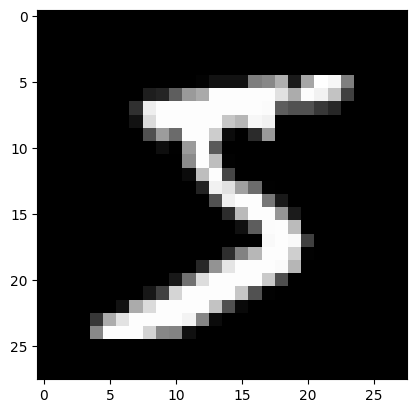

In [11]:
print(im_as_2D_array.shape)
plt.imshow(im_as_2D_array)

In [12]:
x_train_as_2D_arrays = x_train.reshape(60_000, 28, 28) # reshape all back

In [13]:
x_train_as_2D_arrays.shape

(60000, 28, 28)

In [16]:
x_train.shape

(60000, 784)

### Questions (images as vectors):

* What's the image which is the origin of the vector space  ℝ784  where the images live?

* What's its norm?

* What does the norm of any single image compute? I mean how can it be interpreted in terms of images.

* What happens when we multiply an image by a scalar? 0, 0.5, -1?

* What happens when we add, subtract two vectors representing images? Or take the mean?


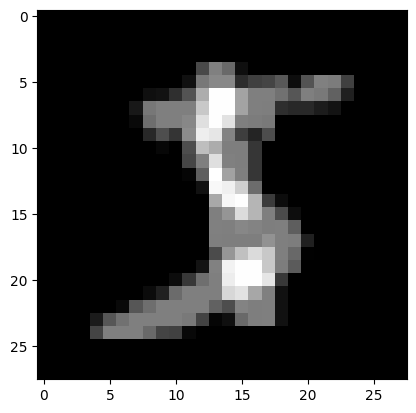

In [17]:
plt.imshow(((x_train[0]+x_train[6])/2).reshape(28,28))

### Task 1: The mean image

Use the data reshaped to the 2-dimensional array, so that each element is a flat vector.

Plot the mean image for each label. Namely the arithmetic mean of all images with the same label.

This is very similar to an exercise from last time!

np.mean works similarly to np.sum!

Hint: use conditions/masks (you can also use y_train!). By masks I mean the arrays of True/False which we used for filtering values.

Don't be afraid of using for loops (if the number of iterations is reletively small). Here you'll need to iterate over all possible label values -- but there aren't too many, so a for loop will not slow things down. It's important to avoid for loops to do heavy computations.

How can we interpret the results? Any hint that people write some digits differently?


In [18]:
'''
Outline:
for each label:
  select vectors corresponding to images with this label
  compute the mean vector using np.mean, careful about axis!
  reshape the result back as an image, and display
  make sure each result is displayed and not just the last one!
'''

'\nOutline:\nfor each label:\n  select vectors corresponding to images with this label\n  compute the mean vector using np.mean, careful about axis!\n  reshape the result back as an image, and display\n  make sure each result is displayed and not just the last one!\n'

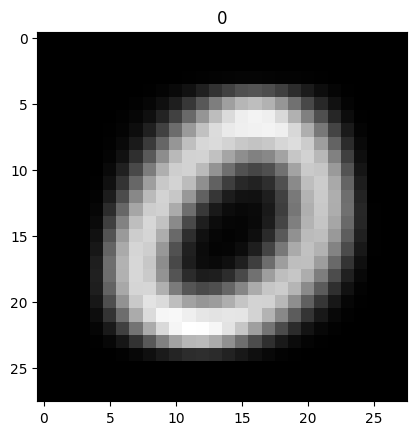

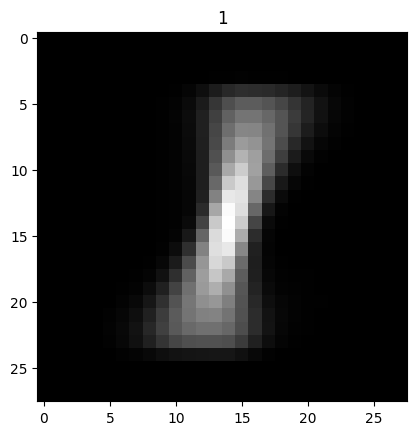

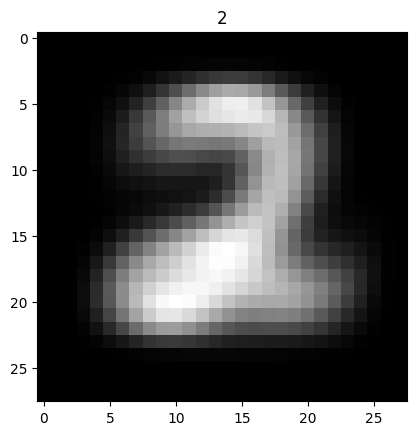

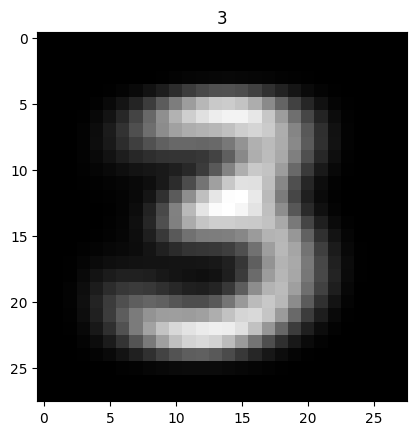

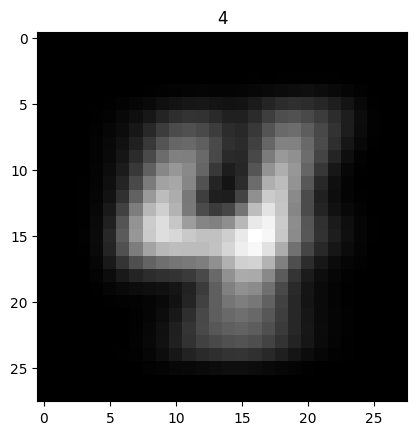

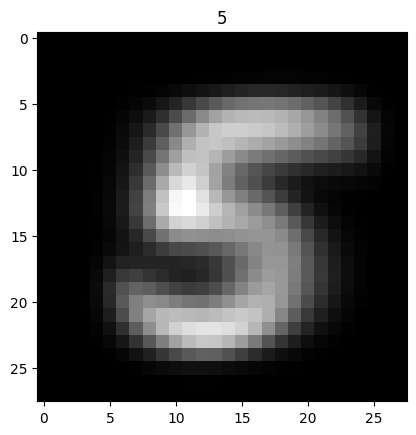

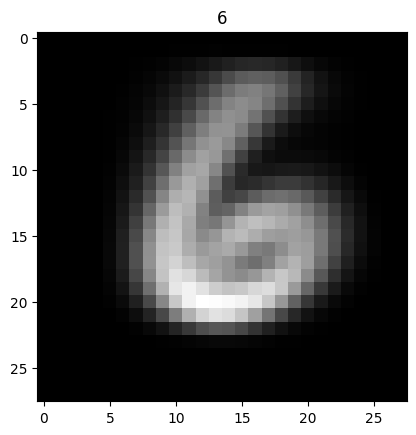

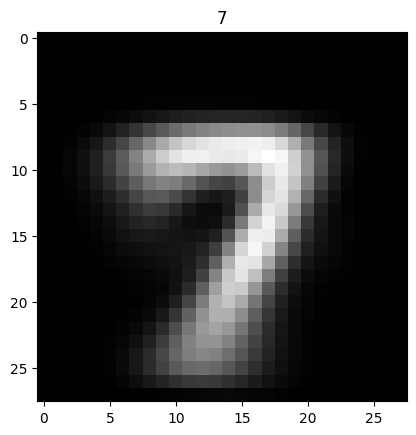

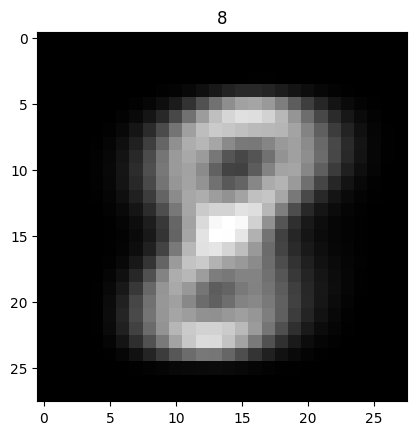

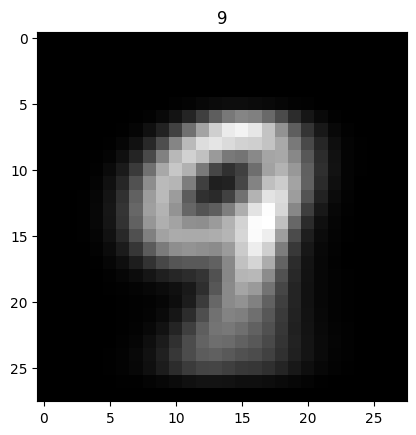

In [19]:
for label in range(10):
    indices = y_train == label
    img_labels = x_train[indices]
    img_mean = np.mean(img_labels, axis=0)
    plt.imshow(img_mean.reshape(28,28))
    plt.title(label)
    plt.show()